In [ ]:
!pip install pandas
!pip install matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
files = {
    0.05: {
        'Explicit': '../OptiNum_A1Errors_Euler_dt0_05.csv',
        'Symplectic': '../OptiNum_A1Errors_Symplectic_dt0_05.csv',
        'Verlet': '../OptiNum_A1Errors_Verlet_dt0_05.csv',
        'RK4': '../OptiNum_A1Errors_Runge4_dt0_05.csv',
    },
    0.001: {
        'Explicit': '../OptiNum_A1Errors_Euler_dt0_001.csv',
        'Symplectic': '../OptiNum_A1Errors_Symplectic_dt0_001.csv',
        'Verlet': '../OptiNum_A1Errors_Verlet_dt0_001.csv',
        'RK4': '../OptiNum_A1Errors_Runge4_dt0_001.csv',
    }
}

for dt, methods in files.items():
    plt.figure(figsize=(8,5))
    for method_name, path in methods.items():
        if not os.path.exists(path):
            print(f"Missing file: {path} — run the C++ program first")
            continue
        df = pd.read_csv(path)
        error_col = 'Error' if 'Error' in df.columns else ' Error'
        plt.plot(df['time'], df[error_col], label=method_name, linewidth=1.4)
    plt.xlabel('time [s]')
    plt.ylabel('Error (distance)')
    plt.title(f'Error vs Time — dt = {dt}')
    plt.legend()
    plt.grid(True)
    safe_dt = str(dt).replace('.', 'p')
    out_png = f'error_vs_time_dt{safe_dt}.png'
    out_pdf = f'error_vs_time_dt{safe_dt}.pdf'
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.savefig(out_pdf)
    print(f"Saved: {out_png} and {out_pdf}")
    plt.show()
    plt.close()

Saved: error_vs_dt.png and error_vs_dt.pdf


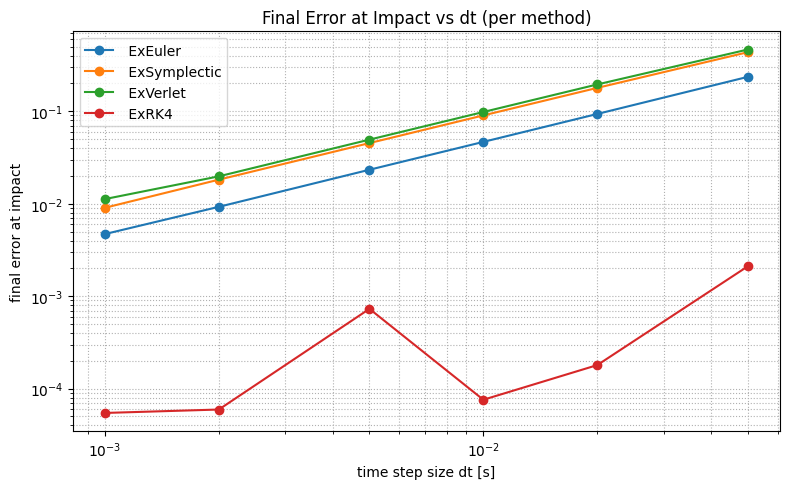

Saved: time_vs_dt.png and time_vs_dt.pdf


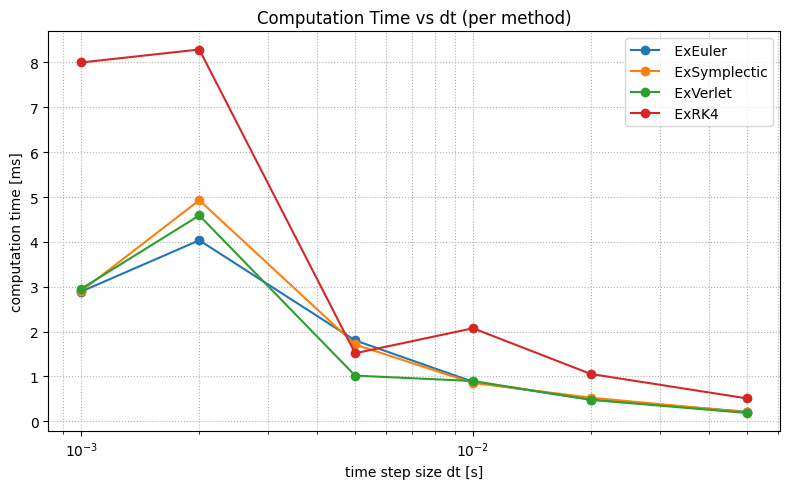

In [13]:
path = '../OptiNum_A1_StepSizeSeries.csv'
if not os.path.exists(path):
    print(f"Missing file: {path} — generate it via ExportStepsizeSeries in the C++ app (Analytic section).")
else:
    df = pd.read_csv(path)
    df = df.copy()
    df['dt'] = df['dt'].astype(float)
    df = df[(df['dt'] >= 1e-4) & (df['dt'] <= 5e-2)].sort_values('dt')

    methods = [' ExEuler',' ExSymplectic',' ExVerlet',' ExRK4']
    err_cols = [f'{m}_error' for m in methods]
    time_cols = [f'{m}_ms' for m in methods]

    plt.figure(figsize=(8,5))
    for m, c in zip(methods, err_cols):
        if c in df.columns:
            plt.plot(df['dt'], df[c], marker='o', label=m)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('time step size dt [s]')
    plt.ylabel('final error at impact')
    plt.title('Final Error at Impact vs dt (per method)')
    plt.grid(True, which='both', ls=':')
    plt.legend()
    plt.tight_layout()
    plt.savefig('error_vs_dt.png', dpi=300)
    plt.savefig('error_vs_dt.pdf')
    print("Saved: error_vs_dt.png and error_vs_dt.pdf")
    plt.show()
    plt.close()

    plt.figure(figsize=(8,5))
    for m, c in zip(methods, time_cols):
        if c in df.columns:
            plt.plot(df['dt'], df[c], marker='o', label=m)
    plt.xscale('log')
    plt.xlabel('time step size dt [s]')
    plt.ylabel('computation time [ms]')
    plt.title('Computation Time vs dt (per method)')
    plt.grid(True, which='both', ls=':')
    plt.legend()
    plt.tight_layout()
    plt.savefig('time_vs_dt.png', dpi=300)
    plt.savefig('time_vs_dt.pdf')
    print("Saved: time_vs_dt.png and time_vs_dt.pdf")
    plt.show()
    plt.close()